# Random Foreest Regressor - Ensemble Learning 
## What is a Random Forest?

A **Random Forest** is an ensemble learning method that builds a large number of decision trees during training and outputs the **mean prediction** of all individual trees for regression tasks.

It is based on two core ideas:

1. **Bootstrap Aggregation (Bagging)** — Each tree is trained on a random subset of the training data drawn *with replacement*.
2. **Feature Randomness** — At each split in a tree, only a random subset of features is considered. This decorrelates the trees from each other.

The combination of these two sources of randomness is what makes Random Forest powerful: it dramatically reduces variance compared to a single deep decision tree, while keeping bias reasonably low.

---
## The Bias-Variance Perspective

A single decision tree grown deep has:
- **Low bias** — it fits the training data very well.
- **High variance** — small changes in training data lead to very different trees.

When average the predictions of many such trees (each trained on a different bootstrap sample), the **bias stays approximately the same** but the **variance drops** by roughly a factor of `n_estimators`, assuming trees are uncorrelated.

The feature randomness (controlled by `max_features`) ensures the trees are not too correlated with each other, which is the critical ingredient that makes the variance reduction effective.

---
## Key Hyperparameters

| Parameter | What It Controls | Typical Default |
|---|---|---|
| `n_estimators` | Number of trees in the forest | 100 |
| `max_features` | Features considered at each split | `1.0` (all) for regression |
| `max_depth` | Maximum depth of each tree | `None` (fully grown) |
| `min_samples_split` | Minimum samples to split a node | 2 |
| `min_samples_leaf` | Minimum samples required at a leaf | 1 |
| `bootstrap` | Whether to use bootstrap samples | `True` |
| `oob_score` | Use out-of-bag samples for validation | `False` |
| `n_jobs` | Parallel jobs for fitting | 1 |


In [10]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

###  Load and Explore the Dataset

We use the **California Housing dataset**, a standard regression benchmark. The target variable is the **median house value** (in units of $100,000) for California districts, derived from the 1990 census.

**Features:**
- `MedInc` — Median income in the block group
- `HouseAge` — Median house age in the block group
- `AveRooms` — Average number of rooms per household
- `AveBedrms` — Average number of bedrooms per household
- `Population` — Block group population
- `AveOccup` — Average number of household members
- `Latitude` — Block group latitude
- `Longitude` — Block group longitude

In [13]:
# Load the California housing dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data          # Feature matrix: 
y = housing.target        # Target vector: 

print(f"Dataset shape  : {X.shape}")
print(f"Target range   : [{y.min():.2f}, {y.max():.2f}]")
print(f"Target mean    : {y.mean():.4f}")
print(f"Target std     : {y.std():.4f}")
print()
print("Feature summary:")
X.describe().T[['mean', 'std', 'min', 'max']]

Dataset shape  : (20640, 8)
Target range   : [0.15, 5.00]
Target mean    : 2.0686
Target std     : 1.1540

Feature summary:


,mean,std,min,max
MedInc,3.870671,1.899822,0.499900,15.000100
HouseAge,28.639486,12.585558,1.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,141.909091
AveBedrms,1.096675,0.473911,0.333333,34.066667
Population,1425.476744,1132.462122,3.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,1243.333333
Latitude,35.631861,2.135952,32.540000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-114.310000


### Visualize the target distribution

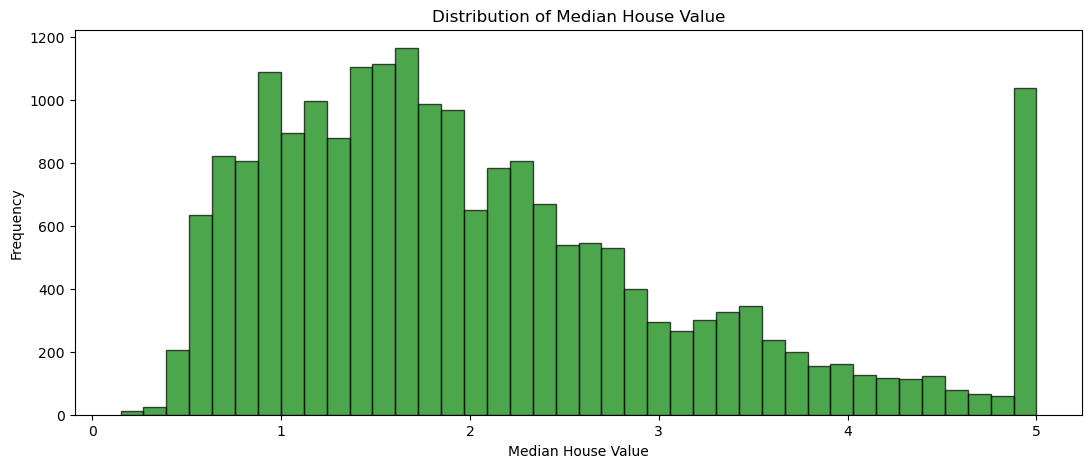

In [70]:
plt.figure(figsize=(13, 5))
plt.hist(y, bins=40, edgecolor='black', alpha=0.7,color='green')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### Correlation heatmap between features

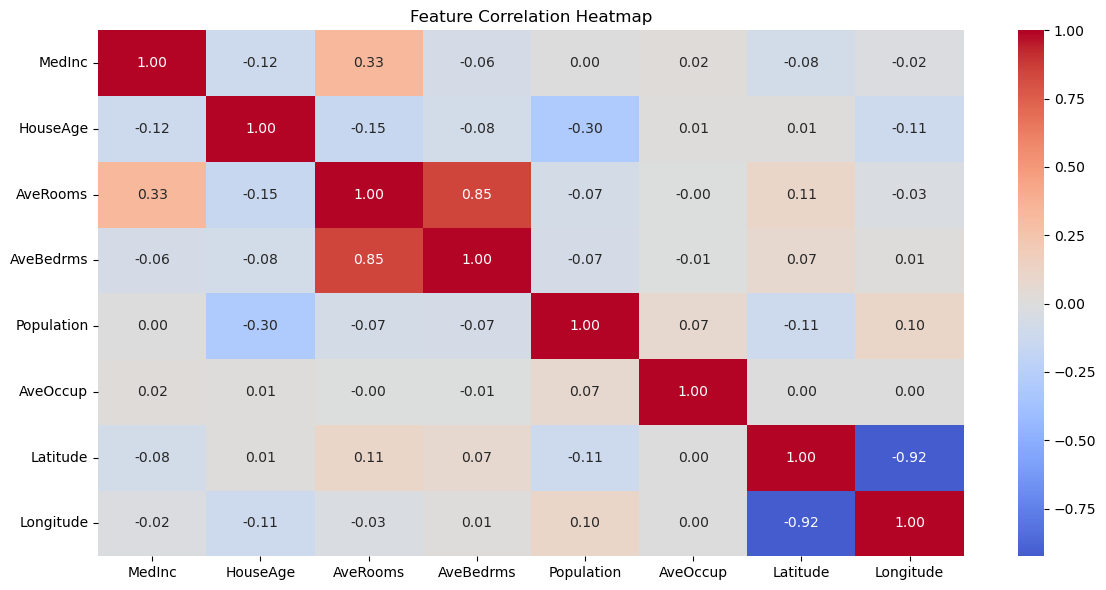

In [60]:
plt.figure(figsize=(12,6))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Train/Test Split
- Hold out 20% of the data for final evaluation.
- The remaining 80% is used for training. Setting `random_state` ensures reproducibility.

In [76]:
# Split data into training and test sets
# test_size=0.2 means 20% of the data is reserved for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 16512
Test samples     : 4128


>Note: Random Forest is tree-based, so feature scaling is NOT required.

### Baseline: Single Decision Tree
- Before fitting the Random Forest, establish a **baseline** using a single Decision Tree Regressor. 

In [85]:
# --- Single Decision Tree (Baseline) ---
tree = DecisionTreeRegressor(
    max_depth=None,       # Fully grown 
    random_state=42
)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_r2   = r2_score(y_test, y_pred_tree)
print("=== Single Decision Tree ===")
print(f"  RMSE   : {tree_rmse:.4f}")
print(f"  R2     : {tree_r2:.4f}")
print(f"  Depth  : {tree.get_depth()}")
print(f"  Leaves : {tree.get_n_leaves()}")

=== Single Decision Tree ===
  RMSE   : 0.7337
  R2     : 0.6126
  Depth  : 33
  Leaves : 15884


### Fit the Random Forest Regressor

Now train the full Random Forest. 

- `n_estimators=200` — 200 trees. 
- `max_features=1.0` — Use all features at each split.
- `oob_score=True` — Enables Out-of-Bag (OOB) evaluation. Each tree only sees ~63.2% of the data during training; the remaining ~36.8% (OOB samples) can be used as a free internal validation set without a separate validation split.
- `n_jobs=-1` — Use all available CPU cores for parallel tree fitting.

In [93]:
# --- Random Forest Regressor ---

rf = RandomForestRegressor(
    n_estimators=200,       # Number of trees
    max_features=1.0,       # All features considered at each split - (default)
    max_depth=None,         # Each tree is fully grown - (low bias)
    min_samples_split=2,    # Minimum samples required to split an internal node
    min_samples_leaf=1,     # Minimum samples required at a leaf node
    bootstrap=True,         # Use bootstrap sampling
    oob_score=True,         # Evaluate on out-of-bag samples
    n_jobs=-1,              # Parallelize across all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)
print("Random Forest fitted successfully.")
print(f"  Number of trees   : {rf.n_estimators}")
print(f"  Number of features: {rf.n_features_in_}")
print(f"  OOB R2 Score      : {rf.oob_score_:.4f}")

Random Forest fitted successfully.
  Number of trees   : 200
  Number of features: 8
  OOB R2 Score      : 0.8125


### Evaluate on the Test Set

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R2 Score

In [99]:
# Predictions on the test set
y_pred_rf = rf.predict(X_test)

# Compute evaluation metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  R2   : {rf_r2:.4f} ")

=== Random Forest Regressor ===
  RMSE : 0.5091
  MAE  : 0.3291
  R2   : 0.8135 


### Features Importance 

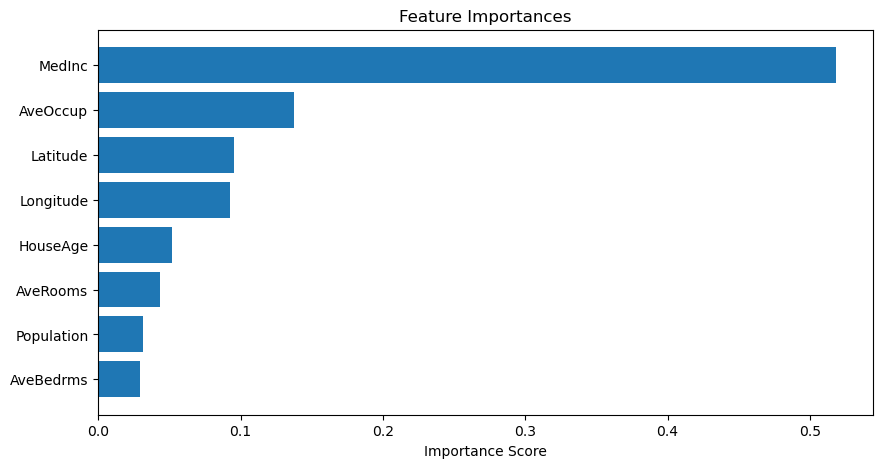

In [120]:
importances = rf.feature_importances_
# Create sorted pairs
sorted_idx = np.argsort(importances)
plt.figure(figsize=(10, 5))
plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.show()

### Cross validation score 

In [124]:
cv_scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
cv_scores

array([0.51856447, 0.70528763, 0.7424827 , 0.63226816, 0.68203259])